# 2D Interpolation Validation

Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.005024, 0.0], Mass: 0.005024
Units set to CGS.


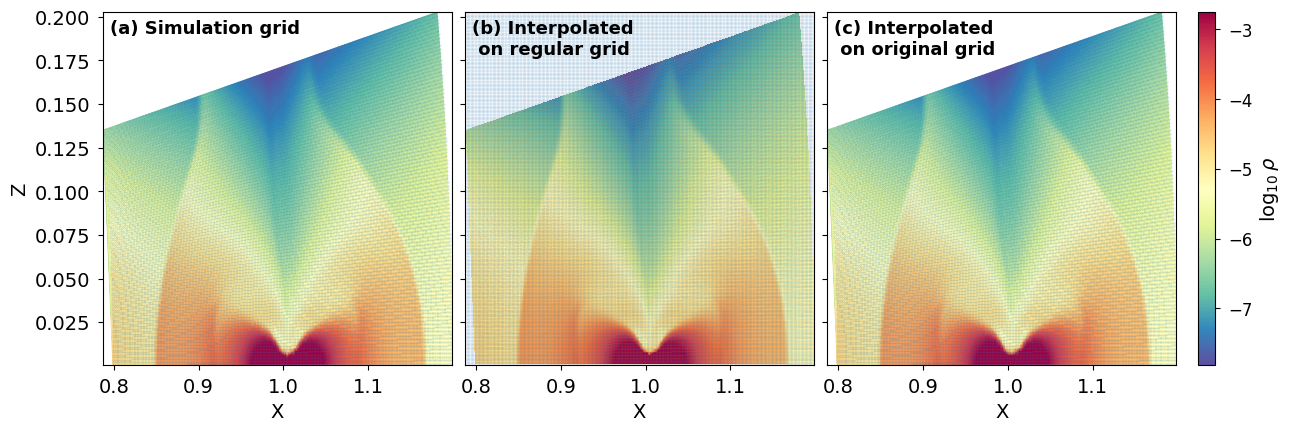

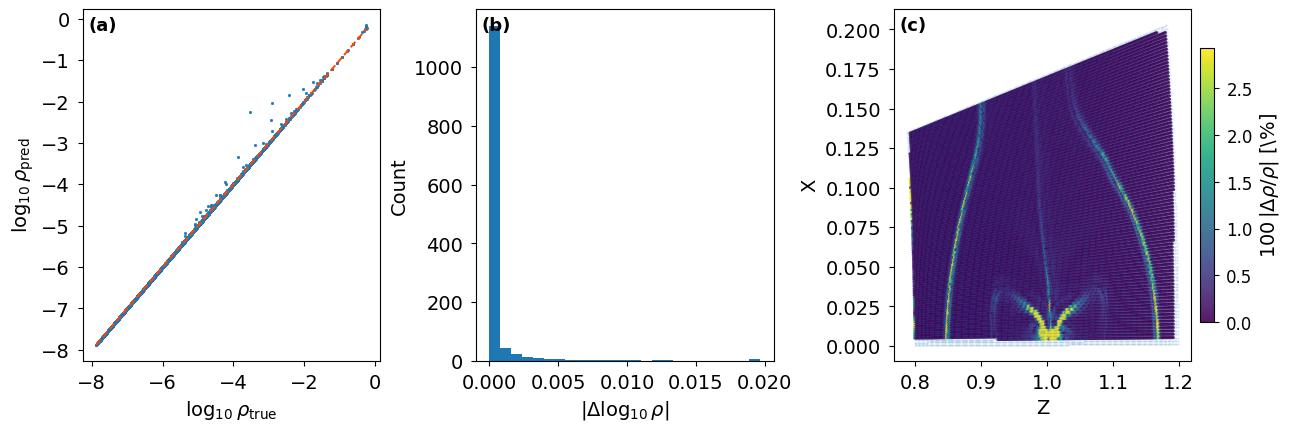

In [1]:
import fargopy as fp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata, RegularGridInterpolator
import matplotlib.tri as mtri
plt.style.use("seaborn-v0_8-paper")
# ============================================================
# CONFIG
# ============================================================
PATH = "/home/alejo/fargo3d/outputs/pds70hr_fid2_rs"
SLICE = "phi=0,r=[0.8,1.2]"
SNAPSHOT = 100
FIELD = "gasdens"
NX_REG = 1024
NZ_REG = 1024
# Solo para mapa de error (si quieres quitar dominancia de bordes)
NBUF_X = 10
NBUF_Z = 10
# Plot styling (ApJ-like)
FS_LABEL = 14
FS_TICK = 14
FS_CBAR_TICK = 12
FS_CBAR_LABEL = 14
FS_PANEL = 13  # (a)(b)(c)
# Background mesh overlay (faded)
S_BG = 1.5
ALPHA_BG_IRR = 0.16
ALPHA_BG_REG = 0.08
# Scatter/hist
SCATTER_S = 4
SCATTER_ALPHA = 1
HIST_BINS = 25
HIST_CLIP_PERCENTILE = 99.5     # display only
ERRMAP_VMAX_PERCENTILE = 99     # display only
# Density shared scaling (log10 rho)
DENS_VMIN_PCT = 1
DENS_VMAX_PCT = 99
# ============================================================
# HELPERS
# ============================================================
def safe_log10(a, floor):
    return np.log10(np.maximum(a, floor))
def compute_metrics(true, pred, eps=1e-300):
    resid = pred - true
    rel = resid / (true + eps)
    absrel = np.abs(rel)
    true_pos = true[true > 0]
    floor = (np.min(true_pos) * 1e-6) if true_pos.size else 1e-300
    dlog = np.log10(np.maximum(pred, floor)) - np.log10(true)
    abs_dlog = np.abs(dlog)
    out = {
        "N": true.size,
        "MAE": np.mean(np.abs(resid)),
        "RMSE": np.sqrt(np.mean(resid**2)),
        "Bias_rel_mean": np.mean(rel),
        "MedAbsRel": np.median(absrel),
        "P16_rel": np.percentile(rel, 16),
        "P84_rel": np.percentile(rel, 84),
        "P95_absrel": np.percentile(absrel, 95),
        "P99_absrel": np.percentile(absrel, 99),
        "RMSE_log10": np.sqrt(np.mean(dlog**2)),
        "MAE_log10": np.mean(np.abs(dlog)),
    }
    for p in [50, 68, 90, 95, 99]:
        out[f"P{p}_abs_dlog10"] = np.percentile(abs_dlog, p)
        out[f"P{p}_mult_factor"] = 10 ** out[f"P{p}_abs_dlog10"]
    return out, rel, absrel, dlog
def format_axes(ax):
    ax.set_xlabel(ax.get_xlabel(), fontsize=FS_LABEL)
    ax.set_ylabel(ax.get_ylabel(), fontsize=FS_LABEL)
    ax.tick_params(axis="both", which="both", labelsize=FS_TICK)
def format_cbar(cbar, label):
    cbar.set_label(label, fontsize=FS_CBAR_LABEL)
    cbar.ax.tick_params(labelsize=FS_CBAR_TICK)
def add_panel_label(ax, label, x=0.02, y=0.98):
    """Add (a)(b)(c) label in axes coords, ApJ-style."""
    ax.text(
        x, y, label,
        transform=ax.transAxes,
        fontsize=FS_PANEL,
        fontweight="bold",
        va="top", ha="left",
    )
# ============================================================
# LOAD IRREGULAR DATA (slice)  -- NO filtering beyond finite
# ============================================================
sim = fp.Simulation(output_dir=PATH)
sim.units("CGS")
sim.set_units(UL=34 * sim.AU, UM=0.76 * sim.MSUN)
data = sim.load_field(fields=FIELD, slice=SLICE, snapshot=SNAPSHOT, interpolate=True)
X_sim = np.asarray(data.var1_mesh[0])
Z_sim = np.asarray(data.var3_mesh[0])
rho_sim = np.asarray(getattr(data, f"{FIELD}_mesh")[0])
x_all = X_sim.ravel()
z_all = Z_sim.ravel()
rho_all = rho_sim.ravel()
m = np.isfinite(x_all) & np.isfinite(z_all) & np.isfinite(rho_all)
x_all, z_all, rho_all = x_all[m], z_all[m], rho_all[m]
# Densidad >0 para log
rho_pos = rho_all[rho_all > 0]
rho_floor_log = (np.min(rho_pos) * 1e-6) if rho_pos.size else 1e-300
points_irr = np.column_stack([x_all, z_all])
# ============================================================
# INTERPOLATION: irregular -> regular
# ============================================================
x_reg = np.linspace(x_all.min(), x_all.max(), NX_REG)
z_reg = np.linspace(z_all.min(), z_all.max(), NZ_REG)
X_reg, Z_reg = np.meshgrid(x_reg, z_reg)
rho_reg_lin = griddata(points_irr, rho_all, (X_reg, Z_reg), method="linear")   # NaNs fuera del hull
rho_reg_nn  = griddata(points_irr, rho_all, (X_reg, Z_reg), method="nearest") # siempre definido
# Para PLOTS (densidad), usamos un campo sin agujeros:
rho_reg_plot = np.where(np.isfinite(rho_reg_lin), rho_reg_lin, rho_reg_nn)
# ============================================================
# BACK TO ORIGINAL GRID
# ============================================================
interp_plot = RegularGridInterpolator(
    (z_reg, x_reg), rho_reg_plot,
    method="linear", bounds_error=False, fill_value=np.nan
)
rho_back_plot = interp_plot(np.column_stack([z_all, x_all]))
interp_pure = RegularGridInterpolator(
    (z_reg, x_reg), rho_reg_lin,
    method="linear", bounds_error=False, fill_value=np.nan
)
rho_back_pure = interp_pure(np.column_stack([z_all, x_all]))
# ============================================================
# DATAFRAMES (solo para error/estadística)
# ============================================================
ok = np.isfinite(rho_back_pure) & np.isfinite(rho_all) & (rho_all > 0)
df_points = pd.DataFrame(
    {"x": x_all[ok], "z": z_all[ok], "rho_true": rho_all[ok], "rho_back": rho_back_pure[ok]}
)
metrics_full, rel_signed, rel_abs, dlog10rho = compute_metrics(
    df_points["rho_true"].values, df_points["rho_back"].values
)
df_points["rel_err_signed"] = rel_signed
df_points["rel_err_abs"] = rel_abs
df_points["dlog10rho"] = dlog10rho
df_points["abs_dlog10rho"] = np.abs(dlog10rho)
df_global_full = pd.DataFrame([metrics_full])
# Mascara “core” SOLO para mapa de error (opcional)
if (NBUF_X > 0) or (NBUF_Z > 0):
    dx = (x_reg.max() - x_reg.min()) / (NX_REG - 1)
    dz = (z_reg.max() - z_reg.min()) / (NZ_REG - 1)
    bufx = NBUF_X * dx
    bufz = NBUF_Z * dz
    xmin, xmax = df_points["x"].min(), df_points["x"].max()
    zmin, zmax = df_points["z"].min(), df_points["z"].max()
    mask_core = (
        (df_points["x"] >= xmin + bufx) & (df_points["x"] <= xmax - bufx) &
        (df_points["z"] >= zmin + bufz) & (df_points["z"] <= zmax - bufz)
    )
    df_err = df_points.loc[mask_core].copy()
else:
    df_err = df_points.copy()
# ============================================================
# SHARED DENSITY COLOR SCALE (Figura 1)
# ============================================================
log_rho_true_all = safe_log10(rho_all, rho_floor_log)
log_rho_reg_all  = safe_log10(rho_reg_plot[np.isfinite(rho_reg_plot)], rho_floor_log)
log_rho_back_all = safe_log10(rho_back_plot[np.isfinite(rho_back_plot)], rho_floor_log)
vmin = np.nanpercentile(np.r_[log_rho_true_all, log_rho_reg_all, log_rho_back_all], DENS_VMIN_PCT)
vmax = np.nanpercentile(np.r_[log_rho_true_all, log_rho_reg_all, log_rho_back_all], DENS_VMAX_PCT)
# Error map scale (display only)
vmax_rel = np.percentile(100 * df_err["rel_err_abs"].values, ERRMAP_VMAX_PERCENTILE)
cmap='Spectral_r'
# ============================================================
# FIGURE 1: 3 subplots (a)(b)(c) + un solo colorbar
# ============================================================
fig1, axs1 = plt.subplots(
    1, 3, figsize=(12.8, 4.2),
    constrained_layout=True, sharex=True, sharey=True
)
# (a) Original (irregular)
tri0 = mtri.Triangulation(x_all, z_all)
m0 = axs1[0].tripcolor(
    tri0, safe_log10(rho_all, rho_floor_log),
    shading="gouraud", cmap=cmap,vmin=vmin, vmax=vmax
)
axs1[0].scatter(x_all, z_all, s=S_BG, alpha=ALPHA_BG_IRR)
axs1[0].set_xlabel("X"); axs1[0].set_ylabel("Z")
format_axes(axs1[0]); axs1[0].grid(False)
add_panel_label(axs1[0], "(a) Simulation grid")
# (b) Interpolated on regular grid
m1 = axs1[1].pcolormesh(
    X_reg, Z_reg, safe_log10(rho_reg_lin, rho_floor_log),
    shading="auto",cmap=cmap, vmin=vmin, vmax=vmax
)
step = max(1, NX_REG // 256)
axs1[1].scatter(X_reg[::step, ::step], Z_reg[::step, ::step], s=S_BG, alpha=ALPHA_BG_REG)
axs1[1].scatter(x_all, z_all, s=S_BG, alpha=ALPHA_BG_IRR * 0.6)
axs1[1].set_xlabel("X")
format_axes(axs1[1]); axs1[1].grid(False)
add_panel_label(axs1[1], "(b) Interpolated \n on regular grid")
# (c) Back on original mesh
ok_plot = np.isfinite(rho_back_plot)
triB = mtri.Triangulation(x_all[ok_plot], z_all[ok_plot])
m2 = axs1[2].tripcolor(
    triB, safe_log10(rho_back_plot[ok_plot], rho_floor_log),
    shading="gouraud", cmap=cmap,vmin=vmin, vmax=vmax
)
axs1[2].scatter(x_all, z_all, s=S_BG, alpha=ALPHA_BG_IRR)
axs1[2].set_xlabel("X")
format_axes(axs1[2]); axs1[2].grid(False)
add_panel_label(axs1[2], "(c) Interpolated \n on original grid")
# Shared colorbar (use m1 as reference)
cbar = fig1.colorbar(m1, ax=axs1, fraction=0.025, pad=0.02)
format_cbar(cbar, r"$\log_{10}\rho$")
# ============================================================
# FIGURE 2: 3 subplots (a)(b)(c) + colorbar solo en (c)
# ============================================================
fig2, axs2 = plt.subplots(1, 3, figsize=(12.8, 4.2), constrained_layout=True)
# (a) Pred vs True (log10)
lt = safe_log10(df_err["rho_true"].values, rho_floor_log)
lp = safe_log10(df_err["rho_back"].values, rho_floor_log)
mn, mx = np.nanmin(lt), np.nanmax(lt)
axs2[0].plot([mn, mx], [mn, mx], linestyle="--",color='orangered')
axs2[0].scatter(lt, lp, s=SCATTER_S, alpha=SCATTER_ALPHA)
axs2[0].set_xlabel(r"$\log_{10}\rho_{\rm true}$",fontsize=16)
axs2[0].set_ylabel(r"$\log_{10}\rho_{\rm pred}$",fontsize=16)
format_axes(axs2[0]); axs2[0].grid(False)
add_panel_label(axs2[0], "(a)")
# (b) Histograma |dlog10|
abs_dlog = np.abs(df_err["dlog10rho"].values)
clip = np.percentile(abs_dlog, HIST_CLIP_PERCENTILE)
abs_dlog_plot = np.clip(abs_dlog, 0, clip)
axs2[1].hist(abs_dlog_plot, bins=HIST_BINS, density=True)
axs2[1].set_xlabel(r"$|\Delta\log_{10}\rho|$",fontsize=16)
axs2[1].set_ylabel("Count",size=16)
format_axes(axs2[1]); axs2[1].grid(False)
add_panel_label(axs2[1], "(b)")
# (c) Mapa de error relativo (%)
sc = axs2[2].scatter(
    df_err["x"], df_err["z"],
    c=100 * df_err["rel_err_abs"],
    s=SCATTER_S, alpha=0.90
)
sc.set_clim(0, vmax_rel)
axs2[2].scatter(x_all, z_all, s=S_BG, alpha=ALPHA_BG_IRR)
axs2[2].set_xlabel("Z",fontsize=16)
axs2[2].set_ylabel("X",fontsize=16)
format_axes(axs2[2]); axs2[2].grid(False)
add_panel_label(axs2[2], "(c)")
cbar_err = fig2.colorbar(sc, ax=axs2[2], fraction=0.046, pad=0.02)
format_cbar(cbar_err, r"$100\,|\Delta\rho/\rho|$ [\%]")
plt.savefig('gallery/fargopy-interp-validation_0.png') # Save figure
plt.show()
# OUTPUT OBJECTS:
# df_global_full : 1-row metrics (puro, en puntos válidos)
# df_points      : puntos válidos + errores
# df_err         : subset (core) solo para diagnósticos si NBUF>0


# 3D Interpolation Validation

In [ ]:
import fargopy as fp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator
plt.style.use("seaborn-v0_8-paper")
# ============================================================
# CONFIG
# ============================================================
PATH = "/home/alejo/fargo3d/outputs/pds70hr_fid2_rs"
SNAPSHOT = 100
FIELD = "gasdens"
SLICE = None  # si tu load_field requiere slice, ponlo; si no, deja None
# Selección de dominio: esfera de Hill (ya lo usas en ciencia)
SUBDIVISIONS = 6
Z_CUT = 0.0
# Validación: capa alrededor de la esfera donde interpolas
# Espesor relativo del "shell" alrededor de r=rhill.
# Ajusta: 0.03–0.10 suele ser razonable; más delgado -> menos puntos (más ruido).
SHELL_THICKNESS_FRAC = 0.05  # Δr = frac * rhill
# Blocked K-fold sobre la esfera (angular)
NTH = 12          # bins en theta
NPH = 24          # bins en phi
K = 8
SEED = 123
# Floor para evitar explosiones de error relativo en densidad baja (métrica, no plot de densidad)
DENS_FLOOR_PERCENTILE = 5
# Plot styling
FS_LABEL = 12
FS_TICK = 10
FS_CBAR_LABEL = 12
FS_CBAR_TICK = 10
SCATTER_S = 3
SCATTER_ALPHA = 0.25
HIST_BINS = 160
HIST_CLIP_PERCENTILE = 99.5
ERRMAP_VMAX_PERCENTILE = 99
# ============================================================
# HELPERS
# ============================================================
def format_axes(ax):
    ax.set_xlabel(ax.get_xlabel(), fontsize=FS_LABEL)
    ax.set_ylabel(ax.get_ylabel(), fontsize=FS_LABEL)
    ax.tick_params(axis="both", which="both", labelsize=FS_TICK)
def format_cbar(cbar, label):
    cbar.set_label(label, fontsize=FS_CBAR_LABEL)
    cbar.ax.tick_params(labelsize=FS_CBAR_TICK)
def safe_log10(a, floor):
    return np.log10(np.maximum(a, floor))
def compute_metrics(true, pred, floor_rel, eps=1e-300):
    """
    true, pred > 0 assumed for log metrics.
    floor_rel: floor usado SOLO para evitar blow-ups en error relativo (en denominador)
    """
    resid = pred - true
    rel = resid / (np.maximum(true, floor_rel) + eps)
    absrel = np.abs(rel)
    dlog = np.log10(pred) - np.log10(true)
    abs_dlog = np.abs(dlog)
    out = {
        "N": true.size,
        "MAE": np.mean(np.abs(resid)),
        "RMSE": np.sqrt(np.mean(resid**2)),
        "Bias_rel_mean": np.mean(rel),
        "MedAbsRel": np.median(absrel),
        "P16_rel": np.percentile(rel, 16),
        "P84_rel": np.percentile(rel, 84),
        "P95_absrel": np.percentile(absrel, 95),
        "P99_absrel": np.percentile(absrel, 99),
        "RMSE_log10": np.sqrt(np.mean(dlog**2)),
        "MAE_log10": np.mean(np.abs(dlog)),
    }
    for p in [50, 68, 90, 95, 99]:
        out[f"P{p}_abs_dlog10"] = np.percentile(abs_dlog, p)
        out[f"P{p}_mult_factor"] = 10 ** out[f"P{p}_abs_dlog10"]
    return out, rel, absrel, dlog
def make_angular_blocks(theta, phi, nth, nph):
    """
    theta in [0,pi], phi in [-pi,pi] or [0,2pi)
    returns block_id integer.
    """
    # normaliza phi a [0,2pi)
    phi2 = np.mod(phi, 2*np.pi)
    th_edges = np.linspace(0.0, np.pi, nth + 1)
    ph_edges = np.linspace(0.0, 2*np.pi, nph + 1)
    ith = np.clip(np.digitize(theta, th_edges) - 1, 0, nth - 1)
    iph = np.clip(np.digitize(phi2, ph_edges) - 1, 0, nph - 1)
    block_id = ith + nth * iph
    return block_id, ith, iph
def blocked_kfold(unique_blocks, k, seed):
    rng = np.random.default_rng(seed)
    b = np.array(unique_blocks, copy=True)
    rng.shuffle(b)
    return np.array_split(b, k)
# ============================================================
# LOAD SIMULATION + CUT SPHERE
# ============================================================
sim = fp.Simulation(output_dir=PATH)
sim.units("CGS")
sim.set_units(UL=34 * sim.AU, UM=0.76 * sim.MSUN)
pds70 = sim.load_planets(snapshot=SNAPSHOT)[0]
xp, yp, zp = pds70.pos.x, pds70.pos.y, pds70.pos.z
rhill = pds70.hill_radius
CUT_SPHERE = (xp, yp, zp, rhill)
kwargs = dict(fields=FIELD, snapshot=SNAPSHOT, cut=CUT_SPHERE, interpolate=True)
if SLICE is not None:
    kwargs["slice"] = SLICE
data_sim = sim.load_field(**kwargs)
X = np.asarray(data_sim.var1_mesh[0]).ravel()
Y = np.asarray(data_sim.var2_mesh[0]).ravel()
Z = np.asarray(data_sim.var3_mesh[0]).ravel()
rho = np.asarray(getattr(data_sim, f"{FIELD}_mesh")[0]).ravel()
m = np.isfinite(X) & np.isfinite(Y) & np.isfinite(Z) & np.isfinite(rho)
X, Y, Z, rho = X[m], Y[m], Z[m], rho[m]
# Coordenadas relativas al planeta
dx = X - xp
dy = Y - yp
dz = Z - zp
r = np.sqrt(dx*dx + dy*dy + dz*dz)
# ============================================================
# DEFINE SHELL AROUND r = rhill (domain relevant to your spherical surface)
# ============================================================
dr = SHELL_THICKNESS_FRAC * rhill
shell = (np.abs(r - rhill) <= dr)
# Solo puntos en shell y con rho>0 (para log)
shell &= (rho > 0)
Xs, Ys, Zs, rhos = X[shell], Y[shell], Z[shell], rho[shell]
dxs, dys, dzs = Xs - xp, Ys - yp, Zs - zp
rs = np.sqrt(dxs*dxs + dys*dys + dzs*dzs)
# Ángulos para blocking sobre esfera
theta = np.arccos(np.clip(dzs / rs, -1.0, 1.0))      # [0,pi]
phi = np.arctan2(dys, dxs)                           # [-pi,pi]
# Density floor (métricas relativas)
rho_floor = np.percentile(rhos, DENS_FLOOR_PERCENTILE)
# ============================================================
# BLOCKED K-FOLD ON THE SHELL (theta,phi blocks)
# ============================================================
block_id, ith, iph = make_angular_blocks(theta, phi, NTH, NPH)
unique_blocks = np.unique(block_id)
folds = blocked_kfold(unique_blocks, K, SEED)
# ============================================================
# FIT/TEST: interpolate rho at SHELL points using the FULL 3D irregular cloud
# - For each fold, test points = shell points in selected angular blocks
# - Train points = all volume points EXCEPT those test shell points
#   (so the algorithm must reconstruct them from neighboring volume samples)
# ============================================================
# Prebuild the full cloud arrays
P_all = np.column_stack([X, Y, Z])
rho_all = rho
# Indexing shell points in the full arrays
# We'll map shell points back to indices in (X,Y,Z) with a hash-like approach.
# Safer: use a boolean mask for "is shell point" within the full arrays.
is_shell_full = np.zeros(X.shape[0], dtype=bool)
# We only know shell points by boolean selection already:
is_shell_full[np.where(shell)[0]] = True
rows_fold = []
pred_list = []
true_list = []
theta_list = []
phi_list = []
xyz_list = []
fold_list = []
for i, test_blocks in enumerate(folds, start=1):
    test_shell_mask = is_shell_full.copy()
    # limit to shell points in those angular blocks
    # Create a full-length mask for selected blocks:
    sel_blocks = np.isin(block_id, test_blocks)
    # sel_blocks is defined on shell arrays; map to full indices:
    full_shell_idx = np.where(shell)[0]
    test_idx_shell_full = full_shell_idx[sel_blocks]
    test_shell_mask[:] = False
    test_shell_mask[test_idx_shell_full] = True
    train_mask = ~test_shell_mask  # includes interior + other shell blocks
    # Build interpolator on training points
    P_train = P_all[train_mask]
    rho_train = rho_all[train_mask]
    # Linear (Delaunay) interpolator
    lin = LinearNDInterpolator(P_train, rho_train, fill_value=np.nan)
    # Test points: shell in these blocks
    P_test = P_all[test_shell_mask]
    rho_true = rho_all[test_shell_mask]
    rho_pred = lin(P_test)
    # mask where linear is defined + positive (log domain)
    ok = np.isfinite(rho_pred) & np.isfinite(rho_true) & (rho_true > 0) & (rho_pred > 0)
    rho_true_ok = rho_true[ok]
    rho_pred_ok = rho_pred[ok]
    if rho_true_ok.size == 0:
        rows_fold.append({"fold": i, "N": 0})
        continue
    met, rel, absrel, dlog = compute_metrics(rho_true_ok, rho_pred_ok, floor_rel=rho_floor)
    met_row = {"fold": i, **met}
    rows_fold.append(met_row)
    # Accumulate for global plots (store angular coords of test points too)
    # Need theta/phi for these test points: recompute from positions
    Pt_ok = P_test[ok]
    ddx = Pt_ok[:, 0] - xp
    ddy = Pt_ok[:, 1] - yp
    ddz = Pt_ok[:, 2] - zp
    rr = np.sqrt(ddx*ddx + ddy*ddy + ddz*ddz)
    th_ok = np.arccos(np.clip(ddz / rr, -1.0, 1.0))
    ph_ok = np.arctan2(ddy, ddx)
    true_list.append(rho_true_ok)
    pred_list.append(rho_pred_ok)
    theta_list.append(th_ok)
    phi_list.append(ph_ok)
    xyz_list.append(Pt_ok)
    fold_list.append(np.full(rho_true_ok.size, i))
df_folds = pd.DataFrame(rows_fold)
# Global accumulation
rho_true_g = np.concatenate(true_list) if true_list else np.array([])
rho_pred_g = np.concatenate(pred_list) if pred_list else np.array([])
theta_g = np.concatenate(theta_list) if theta_list else np.array([])
phi_g = np.concatenate(phi_list) if phi_list else np.array([])
P_g = np.vstack(xyz_list) if xyz_list else np.empty((0, 3))
fold_g = np.concatenate(fold_list) if fold_list else np.array([])
# Global metrics
if rho_true_g.size > 0:
    met_g, rel_g, absrel_g, dlog_g = compute_metrics(rho_true_g, rho_pred_g, floor_rel=rho_floor)
    df_global = pd.DataFrame([{**met_g}])
else:
    df_global = pd.DataFrame([{"N": 0}])
# ============================================================
# FIGURES (3 panels): pred vs true, histogram |dlog10|, angular error map
# ============================================================
if rho_true_g.size > 0:
    lt = np.log10(rho_true_g)
    lp = np.log10(rho_pred_g)
    mn, mx = np.min(lt), np.max(lt)
    abs_dlog = np.abs(dlog_g)
    clip = np.percentile(abs_dlog, HIST_CLIP_PERCENTILE)
    abs_dlog_plot = np.clip(abs_dlog, 0, clip)
    vmax_rel = np.percentile(100 * absrel_g, ERRMAP_VMAX_PERCENTILE)
    fig, axs = plt.subplots(1, 3, figsize=(12.8, 4.2), constrained_layout=True)
    # (1) Pred vs True (log10)
    axs[0].scatter(lt, lp, s=SCATTER_S, alpha=SCATTER_ALPHA)
    axs[0].plot([mn, mx], [mn, mx], linestyle="--")
    axs[0].set_xlabel(r"$\log_{10}\rho_{\rm true}$")
    axs[0].set_ylabel(r"$\log_{10}\rho_{\rm pred}$")
    format_axes(axs[0])
    axs[0].grid(False)
    # (2) Hist |dlog10|
    axs[1].hist(abs_dlog_plot, bins=HIST_BINS, density=True)
    axs[1].set_xlabel(r"$|\Delta\log_{10}\rho|$")
    axs[1].set_ylabel("Density")
    format_axes(axs[1])
    axs[1].grid(False)
    # (3) Angular error map on sphere (equirectangular): phi vs theta
    # Use abs relative error in %
    sc = axs[2].scatter(
        np.mod(phi_g, 2*np.pi), theta_g,
        c=100 * absrel_g, s=SCATTER_S, alpha=0.9
    )
    sc.set_clim(0, vmax_rel)
    axs[2].set_xlabel(r"$\phi$ [rad]")
    axs[2].set_ylabel(r"$\theta$ [rad]")
    format_axes(axs[2])
    axs[2].grid(False)
    cbar = fig.colorbar(sc, ax=axs[2], fraction=0.046, pad=0.02)
    format_cbar(cbar, r"$100\,|\Delta\rho/\rho|$ [\%]")
    
plt.savefig('gallery/fargopy-interp-validation_1.png') # Save figure
plt.show()
# ============================================================
# OUTPUTS (NO PRINTS)
# ============================================================
# df_folds  : métricas por fold
# df_global : métricas globales
# You can also save:
# df_folds.to_csv("interp3d_shell_blockedkfold_folds.csv", index=False)
# df_global.to_csv("interp3d_shell_blockedkfold_global.csv", index=False)


In [ ]:
#!/usr/bin/env python3
"""
Convergence of a (mapped) observable on a tessellated sphere centered on the planet,
for half-disk simulations (real data only for z>=0), using:
- NESTED subsampling of the real volume (z>=0) as the training set.
- Manual 3D interpolation with scipy.griddata:
    * method='linear' with 'nearest' fallback (same behavior as your pipeline).
- Evaluation on the FULL SPHERE (including centers with z<0),
  applying geometric reflection to evaluation points (equivalent to reflect=True):
    z_eval_ref = 2*zp - z_eval  if z_eval < zp
- Metrics/statistics computed ONLY on the real upper hemisphere (z>=0): (z_center - zp) >= 0.
- Diagnostics:
    * percentiles of |Δ log10 f| between consecutive levels (only z>=0)
    * NaN fraction of the linear interpolator (only z>=0) before fallback
    * lon-lat map of Δ (only z>=0) + NaN(linear) markers (only z>=0)
Notes:
- SUBDIV grows as ~20*4^s. Avoid huge SUBDIV if N_LEVELS is small.
- For density (positive) we use log10; for velocities adapt the metric (see note at the end).
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import fargopy as fp
from fargopy.flux import Surface
plt.style.use("seaborn-v0_8-paper")
# ============================================================
# CONFIG
# ============================================================
PATH = "/home/alejo/fargo3d/outputs/pds70hr_fid2_rs"
SNAPSHOT = 200
FIELD = "gasdens"  # positive field (density). For velocities, see note at the end.
# Full sphere (includes z<0)
SUBDIV = 5
Z_CUT = False  # full sphere
SPHERE_RADIUS_FACTOR = 0.8
# Convergence: nested training-set sizes (real volume z>=0)
N_LEVELS = [100000, 150000, 250000, 350000, 550000] 
#N_LEVELS = [100000, 150000, 250000, 350000, 550000]  # adjust if memory/time blows up
SEED = 10
# Metrics
PCTS = [50, 68, 90, 95, 99]
LOG_FLOOR_FACTOR = 1e-6  # floor = min(positive)*factor
# Plots
MAP_CLIP_PCT = 99.0
HIST_BINS = 40
# ============================================================
# HELPERS
# ============================================================
def safe_log10(x, floor):
    return np.log10(np.maximum(x, floor))
def compute_convergence_metrics(delta, name="abs_dlog10"):
    out = {
        "N": int(delta.size),
        f"{name}_mean": float(np.mean(delta)) if delta.size else np.nan,
        f"{name}_median": float(np.median(delta)) if delta.size else np.nan,
    }
    for p in PCTS:
        out[f"{name}_P{p}"] = float(np.percentile(delta, p)) if delta.size else np.nan
    return out
def lon_lat_from_centers(xc, yc, zc, center):
    xp, yp, zp = center
    dx = xc - xp
    dy = yc - yp
    dz = zc - zp
    r = np.sqrt(dx * dx + dy * dy + dz * dz) + 1e-300
    lon = np.arctan2(dy, dx)
    lat = np.arcsin(dz / r)
    return lon, lat
def reflect_z(z, z0):
    """Reflect z-coordinates about the plane z=z0 for points below it."""
    z = np.asarray(z)
    zr = z.copy()
    m = z < z0
    zr[m] = 2.0 * z0 - z[m]
    return zr
def griddata_linear_with_fallback(P_train, V_train, P_eval):
    """
    Linear griddata + nearest fallback.
    Returns:
      V_eval: interpolated values (with fallback applied)
      V_lin:  linear-only values (NaN outside the convex hull)
    """
    V_lin = griddata(P_train, V_train, P_eval, method="linear")
    V_nn = griddata(P_train, V_train, P_eval, method="nearest")
    V_eval = np.where(np.isfinite(V_lin), V_lin, V_nn)
    return V_eval, V_lin
# ============================================================
# LOAD SIMULATION + CUT SPHERE
# ============================================================
sim = fp.Simulation(output_dir=PATH)
sim.units("CGS")
sim.set_units(UL=34 * sim.AU, UM=0.76 * sim.MSUN)
planet = sim.load_planets(snapshot=SNAPSHOT)[0]
xp, yp, zp = planet.pos.x, planet.pos.y, planet.pos.z
rhill = planet.hill_radius
CUT_SPHERE = (xp, yp, zp, rhill)
data_sim = sim.load_field(fields=FIELD, snapshot=SNAPSHOT, cut=CUT_SPHERE, interpolate=True)
X = np.asarray(data_sim.var1_mesh[0])
Y = np.asarray(data_sim.var2_mesh[0])
Z = np.asarray(data_sim.var3_mesh[0])
V = np.asarray(getattr(data_sim, f"{FIELD}_mesh")[0])
# Flatten + clean
x_all = X.ravel()
y_all = Y.ravel()
z_all = Z.ravel()
v_all = V.ravel()
m = np.isfinite(x_all) & np.isfinite(y_all) & np.isfinite(z_all) & np.isfinite(v_all)
x_all, y_all, z_all, v_all = x_all[m], y_all[m], z_all[m], v_all[m]
# Keep ONLY real half-disk data: z>=0 relative to the planet plane
m_upper_vol = (z_all - zp) >= 0.0
x_all, y_all, z_all, v_all = x_all[m_upper_vol], y_all[m_upper_vol], z_all[m_upper_vol], v_all[m_upper_vol]
points_all = np.column_stack([x_all, y_all, z_all])
# Log floor for positive fields
v_pos = v_all[v_all > 0]
if v_pos.size == 0:
    raise ValueError("Field has no positive values in z>=0; log10 is not applicable.")
v_floor = np.min(v_pos) * LOG_FLOOR_FACTOR
# ============================================================
# TESSELLATED SPHERE (centers) - FULL SPHERE
# ============================================================
sphere = Surface(
    type="sphere",
    center=(xp, yp, zp),
    radius=SPHERE_RADIUS_FACTOR * rhill,
    z_cut=Z_CUT,  # False => full sphere
    subdivisions=SUBDIV,
)
xcs, ycs, zcs = sphere.centers[:, 0], sphere.centers[:, 1], sphere.centers[:, 2]
lon, lat = lon_lat_from_centers(xcs, ycs, zcs, center=(xp, yp, zp))
# Masks:
mask_upper_centers = (zcs - zp) >= 0.0  # metrics ONLY here (real domain)
# Evaluation points: full sphere but reflect z for centers with z<0
zcs_ref = reflect_z(zcs, zp)
points_sph_ref = np.column_stack([xcs, ycs, zcs_ref])
# ============================================================
# CONVERGENCE: nested subsamples -> maps on sphere (reflect eval)
# ============================================================
rng = np.random.default_rng(SEED)
perm = rng.permutation(v_all.size)
Nmax = max(N_LEVELS)
if Nmax > perm.size:
    raise ValueError(
        f"Nmax={Nmax} > Npoints_upper={perm.size}. Lower N_LEVELS or increase the cut."
    )
maps = []  # V_eval on the full sphere (z<0 evaluated via reflection)
nan_fracs_upper = []  # NaN fraction of linear (pre-fallback) only on upper hemisphere
nan_fracs_all = []  # NaN fraction of linear over the full sphere
for Nk in N_LEVELS:
    idx = perm[:Nk]  # NESTED
    Pk = points_all[idx]
    Vk = v_all[idx]
    V_eval, V_lin = griddata_linear_with_fallback(Pk, Vk, points_sph_ref)
    maps.append(V_eval)
    nan_fracs_upper.append(float(np.mean(~np.isfinite(V_lin[mask_upper_centers]))))
    nan_fracs_all.append(float(np.mean(~np.isfinite(V_lin))))
# ============================================================
# METRICS: Δ between consecutive levels ONLY for z>=0 centers
# ============================================================
rows = []
deltas_for_last = None
nan_mask_last_upper = None
for i in range(len(N_LEVELS) - 1):
    N1, N2 = N_LEVELS[i], N_LEVELS[i + 1]
    f1, f2 = maps[i], maps[i + 1]
    ok = (
        mask_upper_centers
        & np.isfinite(f1)
        & np.isfinite(f2)
        & (f1 > 0)
        & (f2 > 0)
    )
    dlog = np.abs(safe_log10(f2[ok], v_floor) - safe_log10(f1[ok], v_floor))
    met = compute_convergence_metrics(dlog, name="abs_dlog10")
    met.update(
        {
            "N1": int(N1),
            "N2": int(N2),
            "frac_nan_linear_upper_N1": float(nan_fracs_upper[i]),
            "frac_nan_linear_upper_N2": float(nan_fracs_upper[i + 1]),
            "frac_nan_linear_all_N1": float(nan_fracs_all[i]),
            "frac_nan_linear_all_N2": float(nan_fracs_all[i + 1]),
            "N_centers_ok_upper": int(np.sum(ok)),
            "N_centers_total_upper": int(np.sum(mask_upper_centers)),
            "N_centers_total_all": int(f1.size),
        }
    )
    rows.append(met)
    # Store last-pair delta map + last-level linear NaNs for overlay
    if i == len(N_LEVELS) - 2:
        deltas_for_last = np.full(f1.size, np.nan)
        deltas_for_last[ok] = dlog
        idx_last = perm[: N_LEVELS[-1]]
        P_last = points_all[idx_last]
        V_last = v_all[idx_last]
        _, V_lin_last = griddata_linear_with_fallback(P_last, V_last, points_sph_ref)
        nan_mask_last_upper = mask_upper_centers & ~np.isfinite(V_lin_last)
df = pd.DataFrame(rows)
print(
    "\n=== CONVERGENCE (manual griddata; reflect eval on full sphere; metrics ONLY on z>=0) ==="
)
print(df.to_string(index=False))
# ============================================================
# PLOTS
# ============================================================
fig = plt.figure(figsize=(14.5, 4.6), constrained_layout=True)
gs = fig.add_gridspec(1, 3)
# (1) percentile curves
ax0 = fig.add_subplot(gs[0, 0])
xN = df["N2"].values
for p in [50, 90, 95]:
    ax0.plot(xN, df[f"abs_dlog10_P{p}"].values, marker="o", label=f"P{p}")
ax0.set_xscale("log")
ax0.set_xlabel("Training points N ")
ax0.set_ylabel(r"$|\Delta \log_{10} \rho|$")
ax0.legend()
ax0.grid(False)
# (2) histogram for the final pair (only z>=0)
ax1 = fig.add_subplot(gs[0, 1])
dlog_last = deltas_for_last[np.isfinite(deltas_for_last)]
clip = np.percentile(dlog_last, MAP_CLIP_PCT) if dlog_last.size else 0.0
ax1.hist(np.clip(dlog_last, 0, clip), bins=HIST_BINS, density=True)
ax1.set_xlabel(r"$|\Delta \log_{10} \rho|$ ")
ax1.set_ylabel("Count")
ax1.grid(False)
# (3) lon-lat map for the final pair (only centers z>=0) + NaN(linear) overlay
ax2 = fig.add_subplot(gs[0, 2])
okm = (
    mask_upper_centers
    & np.isfinite(lon)
    & np.isfinite(lat)
    & np.isfinite(deltas_for_last)
)
vals = deltas_for_last[okm]
vmax = np.percentile(vals, MAP_CLIP_PCT) if vals.size else 1.0
sc = ax2.scatter(lon[okm], lat[okm], c=np.clip(vals, 0, vmax), s=6, alpha=0.9)
sc.set_clim(0, vmax)
cbar = fig.colorbar(sc, ax=ax2, fraction=0.046, pad=0.02)
cbar.set_label(r"$|\Delta \log_{10} \rho|$ ")
if nan_mask_last_upper is not None and np.any(nan_mask_last_upper):
    ax2.scatter(lon[nan_mask_last_upper], lat[nan_mask_last_upper], s=10, marker="x", alpha=0.9)
ax2.set_xlabel("lon [rad]")
ax2.set_ylabel("lat [rad]")
ax2.set_title("Δ map (final pair, centers z>=0) + NaN(linear) markers")
ax2.grid(False)
plt.savefig('gallery/fargopy-interp-validation_2.png') # Save figure
plt.show()
# Optional save
# out_csv = f"convergence_manual_reflect_{FIELD}_snap{SNAPSHOT}_subdiv{SUBDIV}.csv"
# df.to_csv(out_csv, index=False)
# print("Saved:", out_csv)
"""
NOTE for velocities:
- If FIELD is a velocity component (can be negative), do not use log10.
  Replace:
    dlog = abs(log10(f2) - log10(f1))
  with:
    d = abs(f2 - f1)   (or a norm if validating a full vector)
  and update labels.
- If you want to preserve sign with dynamic range: use asinh
    d = abs(asinh(f2/s0) - asinh(f1/s0))
  with s0 a typical scale.
"""


Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.005024, 0.0], Mass: 0.005024
Units set to CGS.
